In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
df = pd.read_csv("amfizem_ct_betti_features_bins50.csv")

class_names = ["Normal", "Panlobular", "Paraseptal", "Centroacinar"]

print(df.shape)
print(df["class_name"].value_counts())
print(df["label"].value_counts().sort_index())

(1108, 404)
class_name
Normal          329
Panlobular      262
Paraseptal      259
Centroacinar    258
Name: count, dtype: int64
label
0    329
1    262
2    259
3    258
Name: count, dtype: int64


In [4]:
meta_cols = ["image_name", "image_path", "class_name", "label"]
betti_cols = [c for c in df.columns if c not in meta_cols]

print("Betti feature sayısı:", len(betti_cols))

Betti feature sayısı: 400


In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print(train_df["label"].value_counts().sort_index())

print("Val:", val_df.shape)
print(val_df["label"].value_counts().sort_index())

print("Test:", test_df.shape)
print(test_df["label"].value_counts().sort_index())

Train: (775, 404)
label
0    230
1    183
2    181
3    181
Name: count, dtype: int64
Val: (166, 404)
label
0    49
1    39
2    39
3    39
Name: count, dtype: int64
Test: (167, 404)
label
0    50
1    40
2    39
3    38
Name: count, dtype: int64


In [6]:
scaler = StandardScaler()

train_betti = scaler.fit_transform(train_df[betti_cols].values)
val_betti = scaler.transform(val_df[betti_cols].values)
test_betti = scaler.transform(test_df[betti_cols].values)

In [7]:
IMG_SIZE = 518

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
class EmphysemaFourClassFusionDataset(Dataset):
    def __init__(self, dataframe, betti_array, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.betti = betti_array.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.loc[idx, "image_path"]
        label = int(self.df.loc[idx, "label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        betti = torch.tensor(self.betti[idx], dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return image, betti, label

In [9]:
BATCH_SIZE = 8

train_dataset = EmphysemaFourClassFusionDataset(train_df, train_betti, train_transform)
val_dataset = EmphysemaFourClassFusionDataset(val_df, val_betti, eval_transform)
test_dataset = EmphysemaFourClassFusionDataset(test_df, test_betti, eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [10]:
class TopologyImageCrossAttentionModel(nn.Module):
    def __init__(
        self,
        betti_dim,
        num_classes=4,
        backbone_name="vit_small_patch14_dinov2",
        pretrained=True,
        freeze_backbone=True,
        attn_heads=4,
        dropout=0.35
    ):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0
        )

        self.embed_dim = self.backbone.num_features

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.topology_encoder = nn.Sequential(
            nn.Linear(betti_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(512, self.embed_dim),
            nn.LayerNorm(self.embed_dim)
        )

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=self.embed_dim,
            num_heads=attn_heads,
            dropout=dropout,
            batch_first=True
        )

        self.fusion_norm = nn.LayerNorm(self.embed_dim * 3)

        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim * 3, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def get_image_tokens(self, x):
        tokens = self.backbone.forward_features(x)

        if isinstance(tokens, dict):
            if "x_norm_patchtokens" in tokens:
                patch_tokens = tokens["x_norm_patchtokens"]
                cls_token = tokens["x_norm_clstoken"]
                return cls_token, patch_tokens
            else:
                tokens = list(tokens.values())[0]

        if tokens.dim() == 3:
            cls_token = tokens[:, 0]
            patch_tokens = tokens[:, 1:]
        else:
            cls_token = tokens
            patch_tokens = tokens.unsqueeze(1)

        return cls_token, patch_tokens

    def forward(self, image, betti):
        cls_token, patch_tokens = self.get_image_tokens(image)

        topo_token = self.topology_encoder(betti)
        topo_query = topo_token.unsqueeze(1)

        attended_topo, _ = self.cross_attention(
            query=topo_query,
            key=patch_tokens,
            value=patch_tokens
        )

        attended_topo = attended_topo.squeeze(1)

        fusion = torch.cat(
            [cls_token, topo_token, attended_topo],
            dim=1
        )

        fusion = self.fusion_norm(fusion)
        logits = self.classifier(fusion)

        return logits

In [11]:
model = TopologyImageCrossAttentionModel(
    betti_dim=len(betti_cols),
    num_classes=4,
    backbone_name="vit_small_patch14_dinov2",
    pretrained=True,
    freeze_backbone=True,
    attn_heads=4,
    dropout=0.35
).to(device)

In [12]:
class_counts = train_df["label"].value_counts().sort_index().values

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

Class counts: [230 183 181 181]
Class weights: tensor([0.2084, 0.2619, 0.2648, 0.2648], device='cuda:0')


In [13]:
def train_one_epoch(model, loader, optimizer, criterion, grad_clip=1.0):
    model.train()
    total_loss = 0

    all_preds = []
    all_labels = []

    for images, betti, labels in loader:
        images = images.to(device)
        betti = betti.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images, betti)
        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=grad_clip
        )

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    return total_loss / len(loader), acc, bal_acc, macro_f1, weighted_f1

In [14]:
def evaluate(model, loader, criterion, num_classes=4):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, betti, labels in loader:
            images = images.to(device)
            betti = betti.to(device)
            labels = labels.to(device)

            logits = model(images, betti)
            loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            total_loss += loss.item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels_np = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    try:
        roc_auc_ovr = roc_auc_score(
            all_labels_np,
            all_probs,
            multi_class="ovr",
            average="macro"
        )
    except:
        roc_auc_ovr = np.nan

    try:
        y_bin = label_binarize(all_labels_np, classes=list(range(num_classes)))
        pr_auc_macro = average_precision_score(
            y_bin,
            all_probs,
            average="macro"
        )
    except:
        pr_auc_macro = np.nan

    return (
        total_loss / len(loader),
        acc,
        bal_acc,
        macro_f1,
        weighted_f1,
        roc_auc_ovr,
        pr_auc_macro,
        all_labels,
        all_preds,
        all_probs
    )

In [15]:
EPOCHS = 100
PATIENCE = 5
MIN_DELTA = 1e-4

best_val_f1 = 0
best_epoch = 0
epochs_without_improvement = 0

best_model_path = "best_dinov2.pth"
best_model_wts = copy.deepcopy(model.state_dict())

history = []

for epoch in range(EPOCHS):
    train_loss, train_acc, train_bal_acc, train_macro_f1, train_weighted_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        grad_clip=1.0
    )

    (
        val_loss,
        val_acc,
        val_bal_acc,
        val_macro_f1,
        val_weighted_f1,
        val_roc_auc,
        val_pr_auc,
        _,
        _,
        _
    ) = evaluate(model, val_loader, criterion, num_classes=4)

    scheduler.step(val_macro_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch + 1,
        "lr": current_lr,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_bal_acc": train_bal_acc,
        "train_macro_f1": train_macro_f1,
        "train_weighted_f1": train_weighted_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_bal_acc": val_bal_acc,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "val_roc_auc_ovr": val_roc_auc,
        "val_pr_auc_macro": val_pr_auc
    })

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"LR: {current_lr:.2e} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Macro-F1: {train_macro_f1:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Val Bal-Acc: {val_bal_acc:.4f} | "
        f"Val ROC-AUC: {val_roc_auc:.4f}"
    )

    if val_macro_f1 > best_val_f1 + MIN_DELTA:
        best_val_f1 = val_macro_f1
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), best_model_path)

        print(f"Best model saved. Epoch: {best_epoch}, Val Macro-F1: {best_val_f1:.4f}")

    else:
        epochs_without_improvement += 1
        print(f"No improvement: {epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        print(f"Best epoch: {best_epoch}")
        print(f"Best Val Macro-F1: {best_val_f1:.4f}")
        break

Epoch [1/100] | LR: 1.00e-04 | Train Loss: 1.1136 | Val Loss: 0.8883 | Train Macro-F1: 0.5417 | Val Macro-F1: 0.7033 | Val Bal-Acc: 0.7055 | Val ROC-AUC: 0.8737
Best model saved. Epoch: 1, Val Macro-F1: 0.7033
Epoch [2/100] | LR: 1.00e-04 | Train Loss: 0.8535 | Val Loss: 0.7413 | Train Macro-F1: 0.6982 | Val Macro-F1: 0.7531 | Val Bal-Acc: 0.7555 | Val ROC-AUC: 0.9241
Best model saved. Epoch: 2, Val Macro-F1: 0.7531
Epoch [3/100] | LR: 1.00e-04 | Train Loss: 0.6930 | Val Loss: 0.6434 | Train Macro-F1: 0.7828 | Val Macro-F1: 0.7640 | Val Bal-Acc: 0.7641 | Val ROC-AUC: 0.9585
Best model saved. Epoch: 3, Val Macro-F1: 0.7640
Epoch [4/100] | LR: 1.00e-04 | Train Loss: 0.5881 | Val Loss: 0.4727 | Train Macro-F1: 0.8400 | Val Macro-F1: 0.8889 | Val Bal-Acc: 0.8872 | Val ROC-AUC: 0.9833
Best model saved. Epoch: 4, Val Macro-F1: 0.8889
Epoch [5/100] | LR: 1.00e-04 | Train Loss: 0.5021 | Val Loss: 0.4492 | Train Macro-F1: 0.8781 | Val Macro-F1: 0.8944 | Val Bal-Acc: 0.8923 | Val ROC-AUC: 0.9872

In [16]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

(
    test_loss,
    test_acc,
    test_bal_acc,
    test_macro_f1,
    test_weighted_f1,
    test_roc_auc,
    test_pr_auc,
    y_true,
    y_pred,
    y_prob
) = evaluate(model, test_loader, criterion, num_classes=4)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test Balanced Accuracy:", test_bal_acc)
print("Test Macro F1:", test_macro_f1)
print("Test Weighted F1:", test_weighted_f1)
print("Test ROC-AUC OVR:", test_roc_auc)
print("Test PR-AUC Macro:", test_pr_auc)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

cm = confusion_matrix(y_true, y_pred)
cm

Test Loss: 0.4504479595593044
Test Accuracy: 0.9281437125748503
Test Balanced Accuracy: 0.9227226720647773
Test Macro F1: 0.9269019868030878
Test Weighted F1: 0.9275938015217873
Test ROC-AUC OVR: 0.9829547451457306
Test PR-AUC Macro: 0.9581290368385648
              precision    recall  f1-score   support

      Normal     0.8772    1.0000    0.9346        50
  Panlobular     0.9500    0.9500    0.9500        40
  Paraseptal     0.9706    0.8462    0.9041        39
Centroacinar     0.9444    0.8947    0.9189        38

    accuracy                         0.9281       167
   macro avg     0.9356    0.9227    0.9269       167
weighted avg     0.9317    0.9281    0.9276       167



array([[50,  0,  0,  0],
       [ 0, 38,  0,  2],
       [ 4,  2, 33,  0],
       [ 3,  0,  1, 34]])

In [17]:
def classwise_sensitivity_specificity(cm, class_names):
    results = []

    for i, name in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0

        results.append({
            "class": name,
            "sensitivity_recall": sensitivity,
            "specificity": specificity,
            "precision_ppv": precision,
            "npv": npv
        })

    return pd.DataFrame(results)

classwise_df = classwise_sensitivity_specificity(cm, class_names)
classwise_df

,class,sensitivity_recall,specificity,precision_ppv,npv
0,Normal,1.000000,0.940171,0.877193,1.000000
1,Panlobular,0.950000,0.984252,0.950000,0.984252
2,Paraseptal,0.846154,0.992188,0.970588,0.954887
3,Centroacinar,0.894737,0.984496,0.944444,0.969466


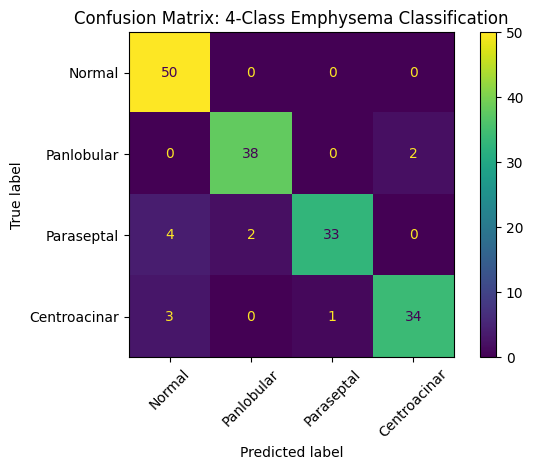

In [18]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(values_format="d")
plt.xticks(rotation=45)
plt.title("Confusion Matrix: 4-Class Emphysema Classification")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

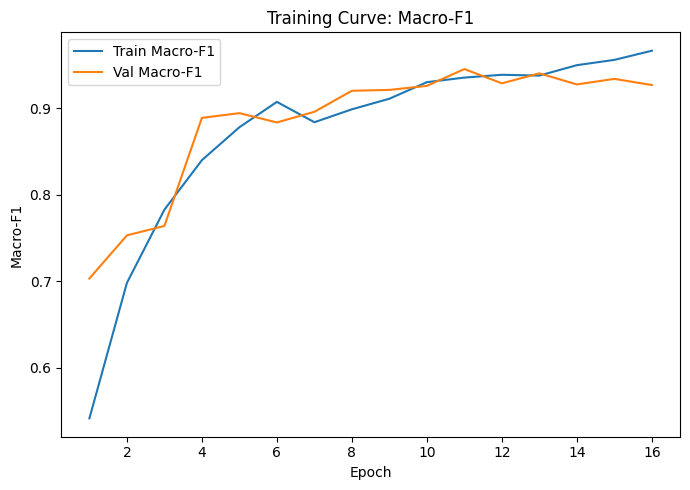

In [19]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train Macro-F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Val Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Training Curve: Macro-F1")
plt.legend()
plt.tight_layout()
plt.savefig("training_macro_f1.png", dpi=300)
plt.show()

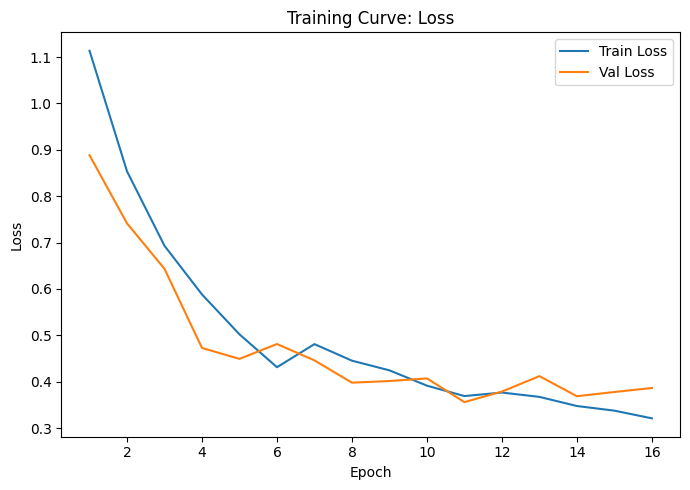

In [20]:
plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve: Loss")
plt.legend()
plt.tight_layout()
plt.savefig("training_loss.png", dpi=300)
plt.show()